# Task 2B - 07 Final allocation, schedule and policy
Writes the exact-solver allocations as **new** files (the teammate's `submission_task2b.csv` is not touched), validates them again from disk, builds the trip plan and stop schedule, and generates the one-page policy from the solved numbers.

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.append('../../tools/task2b')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json, time
from task2b_common import *
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 50); pd.set_option('display.max_rows', 120)
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': .25})
for d in (METRICS, FIGURES, INTERIM): d.mkdir(parents=True, exist_ok=True)
scn, fleet, veh, dt, al = load_tables()
sub_team = pd.read_csv(SUBMISSION)            # the teammate's submitted allocation (read-only)
import task2b_exact as X
S = X.S


In [2]:
RECOMMENDED = 'lexicographic'      # the team's written policy: deferred yesterday > chilled > days since served
res = {p: X.solve_exact(p) for p in ('lexicographic', 'weighted')}
out_files = {}
for p, r in res.items():
    s = X.to_submission(r); f = SUBMISSION_DIR / 'predictions' / f'submission_task2b_exact_{p}.csv'; s.to_csv(f, index=False); out_files[p] = f
    ok, msg = official_check(f); print(p, '->', f.name, '|', msg.splitlines()[-1])
    assert ok and independent_check(pd.read_csv(f), scn, fleet, veh, dt, al).violations.sum() == 0
tmpl = pd.read_csv(RAW / 'templates' / 'submission_task2b.csv')
sub = pd.read_csv(out_files[RECOMMENDED])
assert list(sub.columns) == list(tmpl.columns) and list(sub.order_ref) == list(tmpl.order_ref) and list(sub.outlet_id) == list(tmpl.outlet_id)
print('\ncolumns and order_ref/outlet_id order match the template; rows:', len(sub))

lexicographic -> submission_task2b_exact_lexicographic.csv | FEASIBILITY: PASSED - every rule satisfied.


weighted -> submission_task2b_exact_weighted.csv | FEASIBILITY: PASSED - every rule satisfied.

columns and order_ref/outlet_id order match the template; rows: 85


## Trip plan and stop schedule (recommended policy)

In [3]:
t = trip_table(sub, scn, veh, dt, al).sort_values(['vehicle_id', 'trip_id'])
st, late = simulate_submission(sub, S)
t.round(3).to_csv(METRICS / 'exact_trip_plan.csv', index=False); st.to_csv(METRICS / 'exact_stop_schedule.csv', index=False)
print('trips:', len(t), '| vehicles:', t.vehicle_id.nunique(), '| late stops (clock simulation):', late)
t[['vehicle_id', 'trip_id', 'vehicle', 'brand', 'district', 'stops', 'm3', 'm3_cap', 'kg', 'kg_cap', 'trip_min', 'bucket_used', 'bucket_budget']].round(1)

trips: 25 | vehicles: 15 | late stops (clock simulation): 1


,vehicle_id,trip_id,vehicle,brand,district,stops,m3,m3_cap,kg,kg_cap,trip_min,bucket_used,bucket_budget
0,VEH003,1,truck/reefer,Fresh,Gampaha,3,20.7,26.4,3602.9,5510,101,235,270
1,VEH003,2,truck/reefer,Fresh,Kalutara,3,16.0,26.4,2930.2,5510,134,235,270
2,VEH006,1,truck/reefer,Fresh,Gampaha,3,27.4,33.4,5131.5,6840,100,210,270
3,VEH006,2,truck/reefer,Fresh,Colombo,4,28.5,33.4,5279.6,6840,110,210,270
4,VEH007,1,truck/reefer,Fresh,Colombo,2,17.0,19.4,2937.9,3610,62,250,270
5,VEH007,2,truck/reefer,Fresh,Puttalam,1,8.7,19.4,1588.8,3610,188,250,270
6,VEH008,1,truck/ambient,Fresh,Kalutara,7,17.9,22.0,3319.8,3800,243,243,270
7,VEH008,2,truck/ambient,Style,Galle,2,19.7,22.0,1315.7,3800,217,217,480
8,VEH009,1,truck/ambient,Fresh,Colombo,8,29.9,30.0,5705.9,5800,202,202,270
9,VEH009,2,truck/ambient,Tech,Colombo,3,12.8,30.0,4158.1,5800,193,193,480


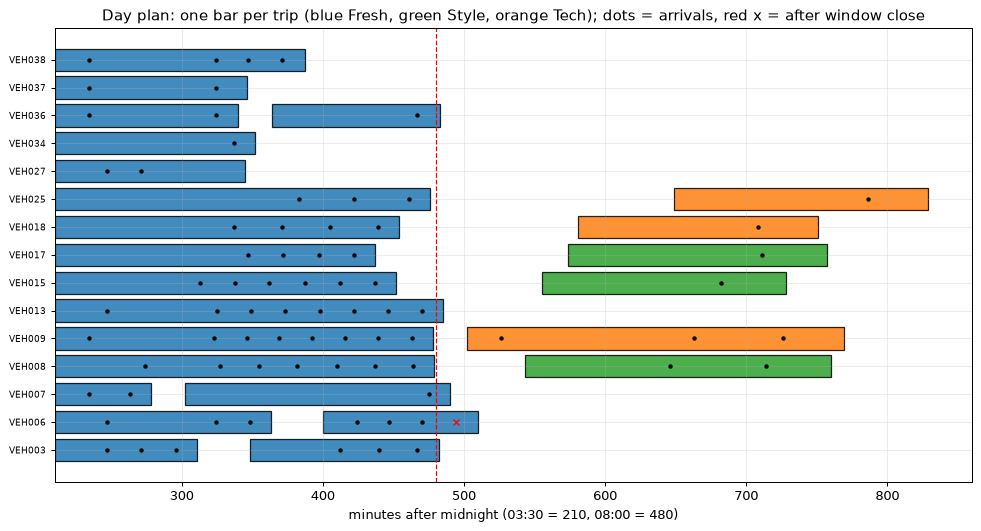

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
vids = sorted(st.vehicle_id.unique()); col = {'Fresh': 'C0', 'Style': 'C2', 'Tech': 'C1'}
for i, v in enumerate(vids):
    for k, g in st[st.vehicle_id == v].groupby('trip_id'):
        b = S.ORDERS[g.order_ref.iloc[0]].brand
        a, z = to_min(g.depart_depot.iloc[0]), max(to_min(x) for x in g.leave)
        ax.barh(i, z - a, left=a, color=col[b], edgecolor='k', alpha=.85)
        for _, r in g.iterrows():
            ax.plot(to_min(r.arrive), i, 'rx' if r.late else 'k.', ms=5)
ax.set_yticks(range(len(vids))); ax.set_yticklabels(vids, fontsize=7); ax.set_xlabel('minutes after midnight (03:30 = 210, 08:00 = 480)'); ax.axvline(480, color='r', ls='--', lw=1)
ax.set_title('Day plan: one bar per trip (blue Fresh, green Style, orange Tech); dots = arrivals, red x = after window close'); plt.tight_layout(); plt.savefig(FIGURES / '07_day_plan.png'); plt.show()

In [5]:
u = t.assign(m3_pct=(t.m3_util * 100).round(0), kg_pct=(t.kg_util * 100).round(0))
print('volume utilisation of trips: median %.0f%%, max %.0f%% | weight: median %.0f%%, max %.0f%%' % (u.m3_pct.median(), u.m3_pct.max(), u.kg_pct.median(), u.kg_pct.max()))
(t.groupby('vehicle').agg(trips=('trip_id', 'size'), m3=('m3', 'sum')).round(1)).T

volume utilisation of trips: median 54%, max 100% | weight: median 57%, max 98%


vehicle,truck/ambient,truck/reefer,van/ambient,van/reefer
trips,15.0,6.0,2.0,2.0
m3,180.0,118.3,7.6,7.9


## One-page policy (generated from the solved numbers)

In [6]:
from textwrap import dedent
k = {p: X.kpis(r) for p, r in res.items()}; kk = k[RECOMMENDED]; kw = k['weighted']
flip_w = json.load(open(METRICS / 'exact_flip.json'))['deferred_yday_flip_weight']
reefers = [v for v in S.AVAILABLE['S1'] if v.temp == 'reefer']; chilled = [o for o in S.ORDERS.values() if o.chilled]
served = res[RECOMMENDED].served_refs(); deferred = [S.ORDERS[r] for r in sorted(set(S.ORDERS) - served)]
rows = '\n'.join('| %s | %s | %s | %s | %.1f | %d | %d | %s |' % (o.ref, o.outlet, o.district, 'chilled' if o.chilled else 'ambient', o.m3, o.deferred_yday, o.days_since,
                 'unavoidable: larger than any compatible vehicle' if S.unavoidable_reason(o, S.AVAILABLE['S1']) else 'reefer capacity') for o in deferred)
only_w = sorted(res['weighted'].served_refs() - served)
txt = dedent(f'''\
# Task 2B - Peak-day allocation policy, scenario S1 (Peliyagoda) - exact solver

**Result ({RECOMMENDED} policy):** {kk['served']}/85 orders served, {kk['m3']} of 409.9 m3; {kk['chilled_served']}/26 chilled orders; all {kk['deferred_yday_served']} outlets skipped yesterday served; {kk['trips']} trips on {kk['vehicles']} vehicles; no ambient stop is planned after its window closes; {late} stop(s) on reefers' second Fresh trips arrive late only by a literal clock (the booklet's 270-minute budget already allows for the return leg). Passes the official `check_allocation.py` and an independent re-check of every rule. Solved exactly (reefer MILP, proven optimal; ambient subset DP): about a minute for the clock-aware model, about 4 seconds for the fast model.

## 1. What limited service
- **Reefer volume:** chilled demand {sum(o.m3 for o in chilled):.1f} m3 vs {sum(v.m3_cap for v in reefers):.1f} m3 for the {len(reefers)} available reefers per wave ({2 * sum(v.m3_cap for v in reefers):.1f} m3 even with two full trips each; five reefers are in the workshop).
- **Pre-dawn minutes:** each vehicle has 270 min; serving every chilled order would need more reefer minutes and trips than exist. Far districts (Puttalam 173 min, Matara 137, Galle 103 outbound) consume a large share of one vehicle's window for one or two stops.
- Ambient trucks and vans are not binding (24 vehicles for about 17 trips).

## 2. Priority policy (strict order, each level optimised and then fixed)
1. Fresh orders **deferred yesterday** - never miss an outlet twice in a row.
2. **Chilled** orders - the most chilled orders served (outlets kept in stock for the festival build-up).
3. Highest **days since last served**.
4. Volume delivered, as a tie-break.
Ambient orders are all served unless physically impossible. Trips are planned so that no stop arrives after its window closes; reefers and constraints are as in the booklet (brand+district per trip, reefer for chilled, vans for van_only, capacity, 270/480-minute budgets, whole orders, at most 2 trips).

## 3. Deferrals
| Order | Outlet | District | Type | m3 | Def. yday | Days | Why |
|---|---|---|---|---|---|---|---|
{rows}

- **Unavoidable (1):** S1-078 is larger than any compatible vehicle (cannot be split); ask the outlet to split it or hire a larger truck.
- **Chosen (reefer capacity):** which chilled orders wait is our policy decision. Serving the Puttalam outlet skipped yesterday costs a 188-minute trip, so {len(deferred) - 1} nearer/larger orders wait instead: they become first-time misses.

## 4. Cost of the choice (exact comparison)
Weighted score instead of the written order: {kw['served']} orders, {kw['m3']} m3, {kw['chilled_served']} chilled, but {kw['deferred_yday_total'] - kw['deferred_yday_served']} outlet skipped for a second day ({only_w}). The score's deferred-yesterday weight (20) is below the value (about {flip_w:.0f}) at which it would choose the same plan.

## 5. Recommendations
- Release a reefer from the workshop: the what-if analysis (notebook 05) gives the exact orders recovered for each of VEH001, VEH002, VEH004, VEH005, VEH035.
- Serve tomorrow's carried-over chilled orders first (they will be `deferred_yesterday = 1`).
- Ask OUT070 to split its 40.7 m3 Style order.
''')
(SUBMISSION_DIR / 'docs' / 'Task2B_policy_exact.md').write_text(txt, encoding='utf-8')
print(txt[:2600])

# Task 2B - Peak-day allocation policy, scenario S1 (Peliyagoda) - exact solver

**Result (lexicographic policy):** 77/85 orders served, 313.83 of 409.9 m3; 19/26 chilled orders; all 10 outlets skipped yesterday served; 25 trips on 15 vehicles; no ambient stop is planned after its window closes; 1 stop(s) on reefers' second Fresh trips arrive late only by a literal clock (the booklet's 270-minute budget already allows for the return leg). Passes the official `check_allocation.py` and an independent re-check of every rule. Solved exactly (reefer MILP, proven optimal; ambient subset DP): about a minute for the clock-aware model, about 4 seconds for the fast model.

## 1. What limited service
- **Reefer volume:** chilled demand 181.6 m3 vs 86.2 m3 for the 4 available reefers per wave (172.4 m3 even with two full trips each; five reefers are in the workshop).
- **Pre-dawn minutes:** each vehicle has 270 min; serving every chilled order would need more reefer minutes and trips than exist. F

## How to use these files
- `predictions/submission_task2b_exact_lexicographic.csv` follows the team's written policy; `predictions/submission_task2b_exact_weighted.csv` reproduces the first solver's outcome with the window-aware plan.
- The teammate's `submission_task2b.csv` is unchanged. To submit one of the exact files, copy it over `submission_task2b.csv` **after** the team decides the policy (human decision, see 05).